# Lab 6 — Gradient Descent & Its Types
## Part 2: A Full PyTorch Training Pipeline with `Dataset` & `DataLoader`

In Part 1 we turned the `DataLoader(batch_size=...)` knob. But where does a `DataLoader` get its data? From a **`Dataset`**. Here we build that machinery ourselves and wire it into a complete pipeline that classifies breast-tumour biopsies as **malignant** or **benign** from 30 measurements.

**In this part you will see how to:**
- Write a custom `Dataset` (`__init__`, `__len__`, `__getitem__`) and let a `DataLoader` batch it.
- Define a model as an `nn.Module` subclass.
- Assemble an end-to-end pipeline: *load → split → scale → encode → tensor → Dataset → DataLoader → train → evaluate*.

## 1. The Pieces
- **`Dataset`** knows how to fetch *one* sample: `__len__` ("how many?") and `__getitem__` ("give me sample `i`").
- **`DataLoader`** asks the `Dataset` for samples and stacks `batch_size` of them into a batch (optionally shuffled).
- **Model as `nn.Module`:** layers go in `__init__`, the computation in `forward`. Ours is logistic regression — one linear layer + a sigmoid:

$$\hat{y} = \sigma(\mathbf{w}^\top\mathbf{x} + b), \qquad \sigma(z) = \tfrac{1}{1+e^{-z}}$$

The training loop (forward → loss → `zero_grad` → backward → step) is the **same one from Part 1**; only the data plumbing around it is new.

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

torch.manual_seed(42)
np.random.seed(42)

## 2. The `Dataset` / `DataLoader` Machinery (toy example)
First meet the machinery on a tiny 10-sample set, so we can *see* what a batch is.

In [ ]:
X_toy, y_toy = make_classification(
    n_samples=10, n_features=2, n_informative=2, n_redundant=0,
    n_classes=2, random_state=42
)
X_toy = torch.tensor(X_toy, dtype=torch.float32)
y_toy = torch.tensor(y_toy, dtype=torch.long)

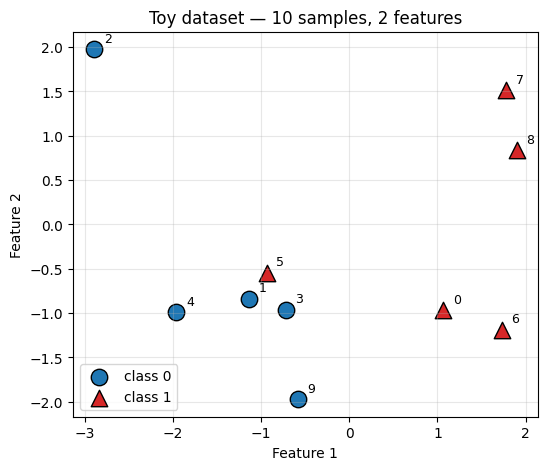

In [ ]:
import matplotlib.pyplot as plt

# tensors -> numpy just for plotting
X_np = X_toy.numpy()
y_np = y_toy.numpy()

plt.figure(figsize=(6, 5))
for cls, color, marker in [(0, 'tab:blue', 'o'), (1, 'tab:red', '^')]:
    pts = X_np[y_np == cls]
    plt.scatter(pts[:, 0], pts[:, 1], c=color, marker=marker,
                s=140, edgecolors='k', label=f'class {cls}')

# label each point with its dataset index (so it ties to dataset[2] etc.)
for i, (f1, f2) in enumerate(X_np):
    plt.annotate(str(i), (f1, f2), textcoords='offset points', xytext=(7, 5), fontsize=9)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Toy dataset — 10 samples, 2 features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

A custom `Dataset` implements exactly three methods. `__getitem__` returns the **single** `(features, label)` pair at one index — the `DataLoader` is what collects many of them into a batch.

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return self.features.shape[0]                      # how many samples

    def __getitem__(self, index):
        return self.features[index], self.labels[index]    # one (features, label) pair

In [ ]:
toy_dataset = CustomDataset(X_toy, y_toy)
print('len:', len(toy_dataset), '| sample[2]:', toy_dataset[2])

len: 10 | sample[2]: (tensor([-2.8954,  1.9769]), tensor(0))


Wrap it in a `DataLoader`: `batch_size=2` gives 5 batches of 2. You wrote no batching code — the loader built the batches purely by calling `__len__` and `__getitem__`. This automates the manual index-slicing you did in Part 1.

In [ ]:
toy_loader = DataLoader(toy_dataset, batch_size=2, shuffle=False)
for batch_features, batch_labels in toy_loader:
    print(batch_features.tolist(), '->', batch_labels.tolist())

[[1.0683389902114868, -0.9700734615325928], [-1.1402153968811035, -0.8387923240661621]] -> [1, 0]
[[-2.895397186279297, 1.9768623113632202], [-0.7206343412399292, -0.96059250831604]] -> [0, 0]
[[-1.962874412536621, -0.9922513365745544], [-0.9382051229476929, -0.5430481433868408]] -> [0, 1]
[[1.7272592782974243, -1.1858267784118652], [1.7773665189743042, 1.5115759372711182]] -> [1, 1]
[[1.8996925354003906, 0.8344448208808899], [-0.5872306227684021, -1.9717174768447876]] -> [1, 0]


## 3. Full Pipeline — Breast-Cancer Diagnosis
30 numeric measurements per tumour; label `diagnosis` is **M** (malignant) or **B** (benign). We classify it with logistic regression, reusing the `CustomDataset` above.

### Load & clean

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)   # id = identifier; Unnamed: 32 = empty column
print('shape:', df.shape)                              # (569, 31) -> 1 label + 30 features
df.head()

shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Split, scale, encode
Column 0 (`diagnosis`) is the label; columns 1–30 are features.
> **Pitfall — scale after splitting** (fit on train only), same as Part 1. And **`BCELoss` needs `float` labels**, so we cast them below.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

encoder = LabelEncoder()                # 'M'/'B' -> 1/0
y_train = encoder.fit_transform(y_train)
y_test  = encoder.transform(y_test)
print('classes:', list(encoder.classes_))

classes: ['B', 'M']


In [ ]:
X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
X_test_tensor  = torch.from_numpy(X_test.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train.astype(np.float32))   # float for BCELoss
y_test_tensor  = torch.from_numpy(y_test.astype(np.float32))

### Wrap in `Dataset` + `DataLoader`
We reuse the **same `CustomDataset`** — a 10-row toy set and a 569-row medical set behind one class. `batch_size=32` is mini-batch GD, the practical default from Part 1.

In [ ]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset  = CustomDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

### Model, optimizer, loss
Logistic regression as an `nn.Module`: layers declared in `__init__`, computation in `forward`.

In [ ]:
class MySimpleNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.linear = nn.Linear(num_features, 1)   # 30 features -> 1 logit
        self.sigmoid = nn.Sigmoid()                # logit -> probability

    def forward(self, features):
        return self.sigmoid(self.linear(features))

model = MySimpleNN(X_train_tensor.shape[1])
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_function = nn.BCELoss()

### Train
The same 5-step loop as Part 1.
> **Pitfall — `[B]` vs `[B, 1]` shape.** `model(x)` returns `[batch, 1]`, but `batch_labels` is flat `[batch]`. Reshape with `.view(-1, 1)` or `BCELoss` broadcasts to nonsense.

In [ ]:
epochs = 25
for epoch in range(epochs):
    for batch_features, batch_labels in train_loader:
        y_pred = model(batch_features)                          # forward
        loss = loss_function(y_pred, batch_labels.view(-1, 1))  # loss ([B,1] shape)
        optimizer.zero_grad()                                   # clear grads
        loss.backward()                                         # backprop
        optimizer.step()                                        # update
    print(f'Epoch {epoch + 1:2d} | loss = {loss.item():.4f}')

Epoch  1 | loss = 0.2074
Epoch  2 | loss = 0.0434
Epoch  3 | loss = 0.1657
Epoch  4 | loss = 0.0325
Epoch  5 | loss = 0.1273
Epoch  6 | loss = 0.1868
Epoch  7 | loss = 0.2587
Epoch  8 | loss = 0.2936
Epoch  9 | loss = 0.1636
Epoch 10 | loss = 0.0373
Epoch 11 | loss = 0.1354
Epoch 12 | loss = 0.0430
Epoch 13 | loss = 0.0211
Epoch 14 | loss = 0.0378
Epoch 15 | loss = 0.0682
Epoch 16 | loss = 0.1975
Epoch 17 | loss = 0.1180
Epoch 18 | loss = 0.2574
Epoch 19 | loss = 0.0266
Epoch 20 | loss = 0.0174
Epoch 21 | loss = 0.0012
Epoch 22 | loss = 0.2890
Epoch 23 | loss = 0.0268
Epoch 24 | loss = 0.2004
Epoch 25 | loss = 0.1097


### Evaluate
> **Pitfall — use `model.eval()` + `torch.no_grad()`** for evaluation: inference-mode layers, no autograd graph, and no accidental training on the test set. We threshold probabilities at `0.5`.

In [ ]:
model.eval()
accuracy_list = []
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        y_pred = (model(batch_features) > 0.5).float()          # prob -> 0/1
        accuracy_list.append((y_pred.view(-1) == batch_labels).float().mean().item())

print(f'Test Accuracy: {sum(accuracy_list) / len(accuracy_list):.4f}')

Test Accuracy: 0.9783


**Note on the threshold.** `0.5` is neutral. Raising it demands more confidence before calling a tumour malignant (higher precision, lower recall). In screening, a *missed* malignancy is the costliest error — so you might even *lower* it. The threshold is a decision tuned to error costs, not a fixed constant.

## 4. Wrap-up
The full pipeline you built:

```
raw CSV -> drop non-features -> train_test_split -> StandardScaler (fit on train)
        -> LabelEncoder -> tensors (float labels) -> CustomDataset
        -> DataLoader(batch_size=32) -> MySimpleNN -> train loop -> eval (threshold)
```

**Takeaways:** a `Dataset` answers *"how many?"* and *"give me sample i"*, and a `DataLoader` turns that into shuffled batches — the same two abstractions scale from 10 rows to millions. Writing the model as an `nn.Module` (layers in `__init__`, math in `forward`) is the general pattern. The training loop is identical to Part 1; the new skill is assembling correct data plumbing and evaluation — watching for the two silent bugs: *scale on train only* and *match the `[B,1]` label shape*.

## 5. Quick Quiz
1. A `DataLoader` produced batches of 32 with no batching code from you. Which two `CustomDataset` methods did it call, and what does each return?
2. Referring to Part 1, what happens to *time per epoch* and *convergence per epoch* if you set `batch_size=1` here?
3. Name one concrete thing that can go wrong if you drop `torch.no_grad()` during evaluation on a large test set.

## 6. Bonus (early finishers)
- Evaluate at thresholds `0.3`, `0.5`, `0.8` — which would you defend for cancer screening?
- Add a hidden layer to `MySimpleNN` (`Linear(n,16) -> ReLU -> Linear(16,1) -> Sigmoid`) — does accuracy improve?
- Retrain with `batch_size=1` and `batch_size=len(train_dataset)` and compare — do you reproduce the Part 1 tradeoff on real data?